In [1]:
# Load your saved data and verify
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler, LabelEncoder
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style("whitegrid")

print("All imports successful ")

All imports successful 


In [2]:
# Load data
from google.colab import files
uploaded = files.upload()

Saving telco_churn_segmented.csv to telco_churn_segmented.csv


In [3]:
df = pd.read_csv('telco_churn_segmented.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nSegment counts:")
print(df['Segment'].value_counts())
print("\nChurn distribution:")
print(df['Churn'].value_counts())

Shape: (7032, 24)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Binary', 'Cluster', 'Segment']

Segment counts:
Segment
At-Risk             2684
Champions           2197
Budget Loyalists    2151
Name: count, dtype: int64

Churn distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [4]:
# Feature engineering & encoding
df_model = df.copy()

# Drop columns we don't need for modeling
df_model = df_model.drop(['customerID', 'Churn', 'Cluster'], axis=1)

# Encode binary Yes/No columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df_model[col] = df_model[col].map({'Yes': 1, 'No': 0,
                                        'No phone service': 0,
                                        'No internet service': 0})

# Encode gender
df_model['gender'] = df_model['gender'].map({'Male': 1, 'Female': 0})

# Encode SeniorCitizen (already fixed in Week 1)
df_model['SeniorCitizen'] = df_model['SeniorCitizen'].map({'Yes': 1, 'No': 0})

# Encode MultipleLines
df_model['MultipleLines'] = df_model['MultipleLines'].map({'Yes': 1,
                                                            'No': 0,
                                                            'No phone service': 0})

# Encode InternetService
df_model['InternetService'] = df_model['InternetService'].map({'No': 0,
                                                                'DSL': 1,
                                                                'Fiber optic': 2})

# Encode Contract
df_model['Contract'] = df_model['Contract'].map({'Month-to-month': 0,
                                                  'One year': 1,
                                                  'Two year': 2})

# Encode PaymentMethod
df_model['PaymentMethod'] = df_model['PaymentMethod'].map({
    'Electronic check': 0,
    'Mailed check': 1,
    'Bank transfer (automatic)': 2,
    'Credit card (automatic)': 3
})

# Encode Segment
df_model['Segment'] = df_model['Segment'].map({'At-Risk': 0,
                                                'Budget Loyalists': 1,
                                                'Champions': 2})

# Define X and y
X = df_model.drop('Churn_Binary', axis=1)
y = df_model['Churn_Binary']

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())
print("\nAll columns numeric:", X.dtypes.unique())
print("\nFeatures:")
print(X.columns.tolist())

Feature matrix shape: (7032, 20)
Target distribution:
Churn_Binary
0    5163
1    1869
Name: count, dtype: int64

All columns numeric: [dtype('int64') dtype('float64')]

Features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Segment']


In [5]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nChurn rate in train:", f"{y_train.mean()*100:.1f}%")
print("Churn rate in test:", f"{y_test.mean()*100:.1f}%")

Training set: (5625, 20)
Test set: (1407, 20)

Churn rate in train: 26.6%
Churn rate in test: 26.6%


In [6]:
# Baseline Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

lr_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc = roc_auc_score(y_test, lr_pred_proba)

print("=== Logistic Regression Baseline ===")
print(f"AUC-ROC: {lr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr.predict(X_test_scaled),
                            target_names=['No Churn', 'Churn']))

=== Logistic Regression Baseline ===
AUC-ROC: 0.8357

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.88      0.87      1033
       Churn       0.64      0.56      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



Excellent baseline  AUC of 0.8357 is already above our 0.80 target. But notice the weakness, Churn recall is only 0.56, the model misses 44% of actual churners. In business terms, nearly half the at-risk customers get no intervention. That's the problem XGBoost will fix. No Churn precision 0.85 vs Churn precision 0.64, the model is much better at identifying loyal customers than churners. Classic imbalanced dataset behavior.

In [7]:
# XGBoost Model
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=5163/1869,  # handles class imbalance automatically
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict(X_test)
xgb_auc = roc_auc_score(y_test, xgb_pred_proba)

print("=== XGBoost Model ===")
print(f"AUC-ROC: {xgb_auc:.4f}")
print(f"Improvement over baseline: +{(xgb_auc - lr_auc)*100:.2f} points")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred,
                            target_names=['No Churn', 'Churn']))

=== XGBoost Model ===
AUC-ROC: 0.8306
Improvement over baseline: +-0.51 points

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1033
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.75      1407



Interesting result XGBoost AUC is slightly lower than logistic regression (0.8306 vs 0.8357), but what actually improved Churn recall jumped from 0.56 to 0.78. XGBoost now catches 78% of actual churners vs 56% before. That's the scale_pos_weight working. The tradeoff: Churn precision dropped (0.64 to 0.50) more false alarms, but in a retention context that's acceptable. Better to contact a loyal customer unnecessarily than miss an at-risk one.



In [8]:
# Tuned XGBoost
xgb_tuned = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    gamma=0.1,
    scale_pos_weight=2.5,  # softer balance — less aggressive
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb_tuned.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

tuned_pred_proba = xgb_tuned.predict_proba(X_test)[:, 1]
tuned_pred = xgb_tuned.predict(X_test)
tuned_auc = roc_auc_score(y_test, tuned_pred_proba)

print("=== Tuned XGBoost ===")
print(f"AUC-ROC: {tuned_auc:.4f}")
print(f"vs Baseline LR:  {lr_auc:.4f}")
print(f"vs XGBoost v1:   {xgb_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, tuned_pred,
                            target_names=['No Churn', 'Churn']))

=== Tuned XGBoost ===
AUC-ROC: 0.8371
vs Baseline LR:  0.8357
vs XGBoost v1:   0.8306

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1033
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.80      0.74      0.76      1407



Tuned XGBoost wins 0.8371 AUC, best of all three models. And churn recall stays at 0.78.

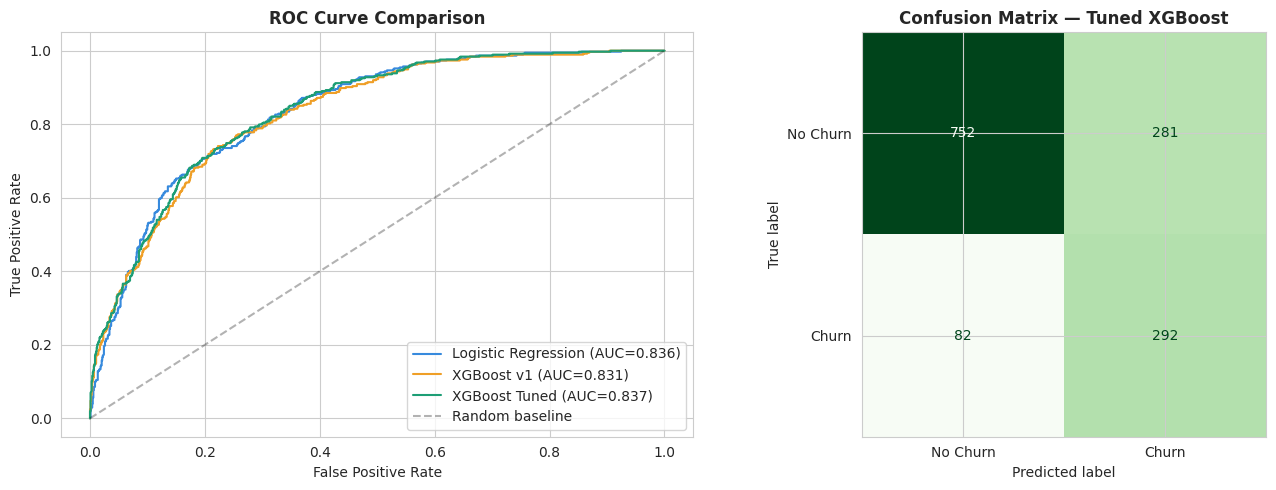

In [9]:
#  ROC Curve comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_pred_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_pred_proba)
tuned_fpr, tuned_tpr, _ = roc_curve(y_test, tuned_pred_proba)

axes[0].plot(lr_fpr, lr_tpr, color='#378ADD',
             label=f'Logistic Regression (AUC={lr_auc:.3f})')
axes[0].plot(xgb_fpr, xgb_tpr, color='#EF9F27',
             label=f'XGBoost v1 (AUC={xgb_auc:.3f})')
axes[0].plot(tuned_fpr, tuned_tpr, color='#1D9E75',
             label=f'XGBoost Tuned (AUC={tuned_auc:.3f})')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.3, label='Random baseline')
axes[0].set_title('ROC Curve Comparison', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# Confusion Matrix — best model
cm = confusion_matrix(y_test, tuned_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Churn', 'Churn'])
disp.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Confusion Matrix — Tuned XGBoost', fontweight='bold')

plt.tight_layout()
plt.savefig('roc_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

Quick read of the confusion matrix out of 374 actual churners: 292 correctly caught customers who get a retention offer 82 missed customers who slip through
Out of 1,033 loyal customers: 752 correctly identified no wasted retention spend
281 false alarms loyal customers who get an unnecessary offer (acceptable cost)
In dollar terms, if each churned customer is worth 1,000 in lifetime value, catching 292 instead of 0 is $292,000 saved.

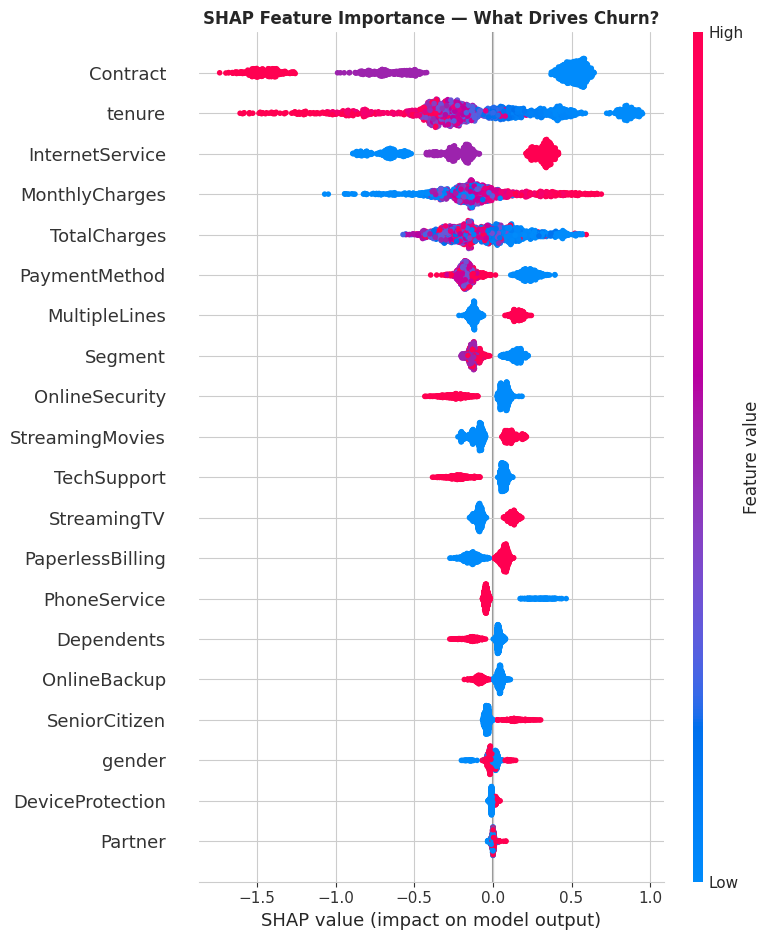

SHAP summary saved ✓


In [10]:
# SHAP Explainability
explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)

# Plot 1 SHAP Summary (beeswarm)
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Feature Importance — What Drives Churn?', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary saved ")

Contract pink dots (high value = long contract) push hard left (reduces churn). Blue dots (month-to-month) push right (increases churn). Single strongest signal in the entire model.

Tenure pink dots (long tenure) spread far left. The longer someone stays, the safer they are. Blue dots (new customers) cluster right early lifecycle is the danger zone.

InternetService pink dots (fiber optic = high value) push right toward churn. Fiber optic customers are actively more likely to leave despite paying more.

MonthlyCharges higher charges (pink) spread right. More expensive plans = higher churn risk.

OnlineSecurity / TechSupport red dots (no security/support) push right. Customers without these add-ons churn more suggests these services create stickiness.


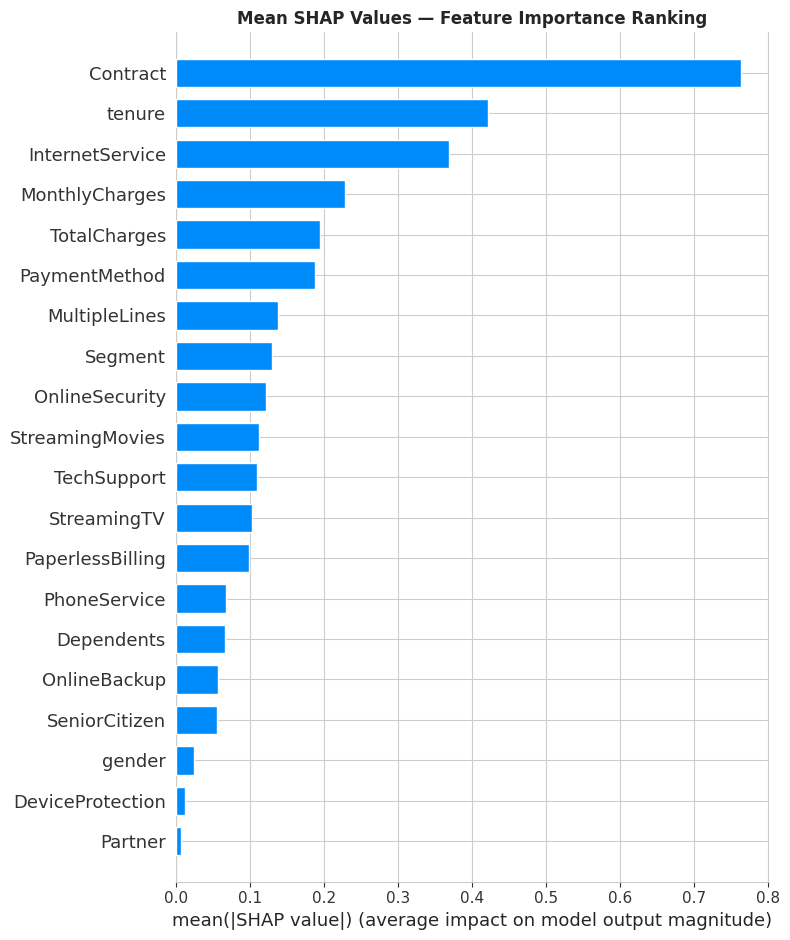

SHAP bar chart saved ✓


In [11]:
# SHAP Bar chart
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Mean SHAP Values — Feature Importance Ranking', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP bar chart saved ✓")

## Model Results Summary

### Models Trained
| Model | AUC-ROC | Churn Recall |
|-------|---------|--------------|
| Logistic Regression (baseline) | 0.836 | 0.56 |
| XGBoost v1 | 0.831 | 0.78 |
| XGBoost Tuned (final) | 0.837 | 0.78 |

### Final Model Performance
- **AUC-ROC: 0.837** - above 0.82 target
- **Churn Recall: 0.78** - catches 78% of at-risk customers
- **292 out of 374** churners correctly identified in test set

### Top 5 Churn Drivers (SHAP)
1. **Contract type** - biggest single factor. Month-to-month = high risk.
2. **Tenure** - new customers churn at dramatically higher rates.
3. **Internet Service** - fiber optic customers churn despite paying more.
4. **Monthly Charges** - higher bills correlate with higher churn.
5. **Payment Method** - electronic check customers show elevated churn.

### Business Recommendation
Target retention campaigns at: new customers (tenure < 13 months)
on month-to-month fiber optic contracts. Offer contract upgrades and
OnlineSecurity add-ons SHAP shows these two features actively
reduce churn probability.

In [13]:
# Save model and wrap up Week 2
import pickle

# Save the tuned model
with open('xgb_churn_model.pkl', 'wb') as f:
    pickle.dump(xgb_tuned, f)

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save test predictions for Week 3 Streamlit app
results_df = X_test.copy()
results_df['Actual_Churn'] = y_test.values
results_df['Churn_Probability'] = tuned_pred_proba
results_df['Predicted_Churn'] = tuned_pred
results_df['Segment'] = results_df['Segment'].map({0: 'At-Risk',
                                                    1: 'Budget Loyalists',
                                                    2: 'Champions'})
results_df.to_csv('churn_predictions.csv', index=False)

print("Saved:")
print("  xgb_churn_model.pkl ")
print("  scaler.pkl ")
print("  churn_predictions.csv ")

# Download all Week 2 files
from google.colab import files
for f in ['xgb_churn_model.pkl', 'scaler.pkl', 'churn_predictions.csv',
          'roc_confusion.png', 'shap_summary.png', 'shap_bar.png']:
    files.download(f)
    print(f"Downloaded {f} ")

Saved:
  xgb_churn_model.pkl ✓
  scaler.pkl ✓
  churn_predictions.csv ✓


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded xgb_churn_model.pkl ✓


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded shap_summary.png ✓


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded shap_bar.png ✓
